In [1]:
from langgraph.graph import StateGraph, START, END
from langchain_openai import ChatOpenAI
from typing import TypedDict
from dotenv import load_dotenv


In [2]:
load_dotenv()



True

In [3]:
model = ChatOpenAI()



In [4]:
class BlogState(TypedDict):
    title:str
    outline:str
    content:str



In [5]:
def create_outline(state:BlogState)->BlogState:

    # fetch title
    title = state['title']

    # call llm to create outline
    prompt = f"Create a detailed outline for a blog post with the title: {title}"
    outline = model.invoke(prompt).content

    # update state
    state['outline'] = outline

    return state



In [6]:
def create_blog(state:BlogState)->BlogState:

    # fetch outline and title
    title = state['title']
    outline = state['outline']

    # call llm to create blog content
    prompt = f"Write a blog post with the title: {title} and the following outline: {outline}"
    content = model.invoke(prompt).content

    # update state
    state['content'] = content

    return state



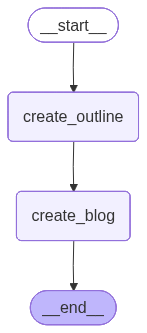

In [ ]:
graph = StateGraph(BlogState)

# add nodes 
graph.add_node("create_outline", create_outline)
graph.add_node("create_blog", create_blog)

# add edges
graph.add_edge(START, "create_outline")
graph.add_edge("create_outline", "create_blog")
graph.add_edge("create_blog", END)

# compile
workflow=graph.compile()

In [ ]:
initial_state = {'title': "The Future of AI"}
final_state = workflow.invoke(initial_state)
print(final_state)